In [17]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *
from utils.Phase_diversity_helpers import *

In [19]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [20]:
N_order = 3               # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05            # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm
alpha = np.arcsin(num_apt / n)

#20 microns
L_ffp = 0.02
#512 x 512
grid_ffp = 512
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
#CONJUGATE BFP LENGTH
grid_bfp = grid_ffp
L_bfp = (lambd * f * grid_bfp) / L_ffp
microscope = Microscope(N_order, lambd, n, num_apt, f, mag, w_0, L_bfp, grid_bfp)
x, y = grid.get_xy()
x_bfp = x * (L_bfp/ L_ffp)
y_bfp = y * (L_bfp/ L_ffp)

In [21]:
f = np.load("images/usaf_resolution.npy")

In [22]:
true_modes = [[0, 4]]
true_c = [0.1]
true_aberration = Aberration(true_modes, true_c)

In [23]:
def add_gaussian_noise(image, mean, std_dev, rng):
    return image + rng.normal(mean, std_dev, np.shape(image))

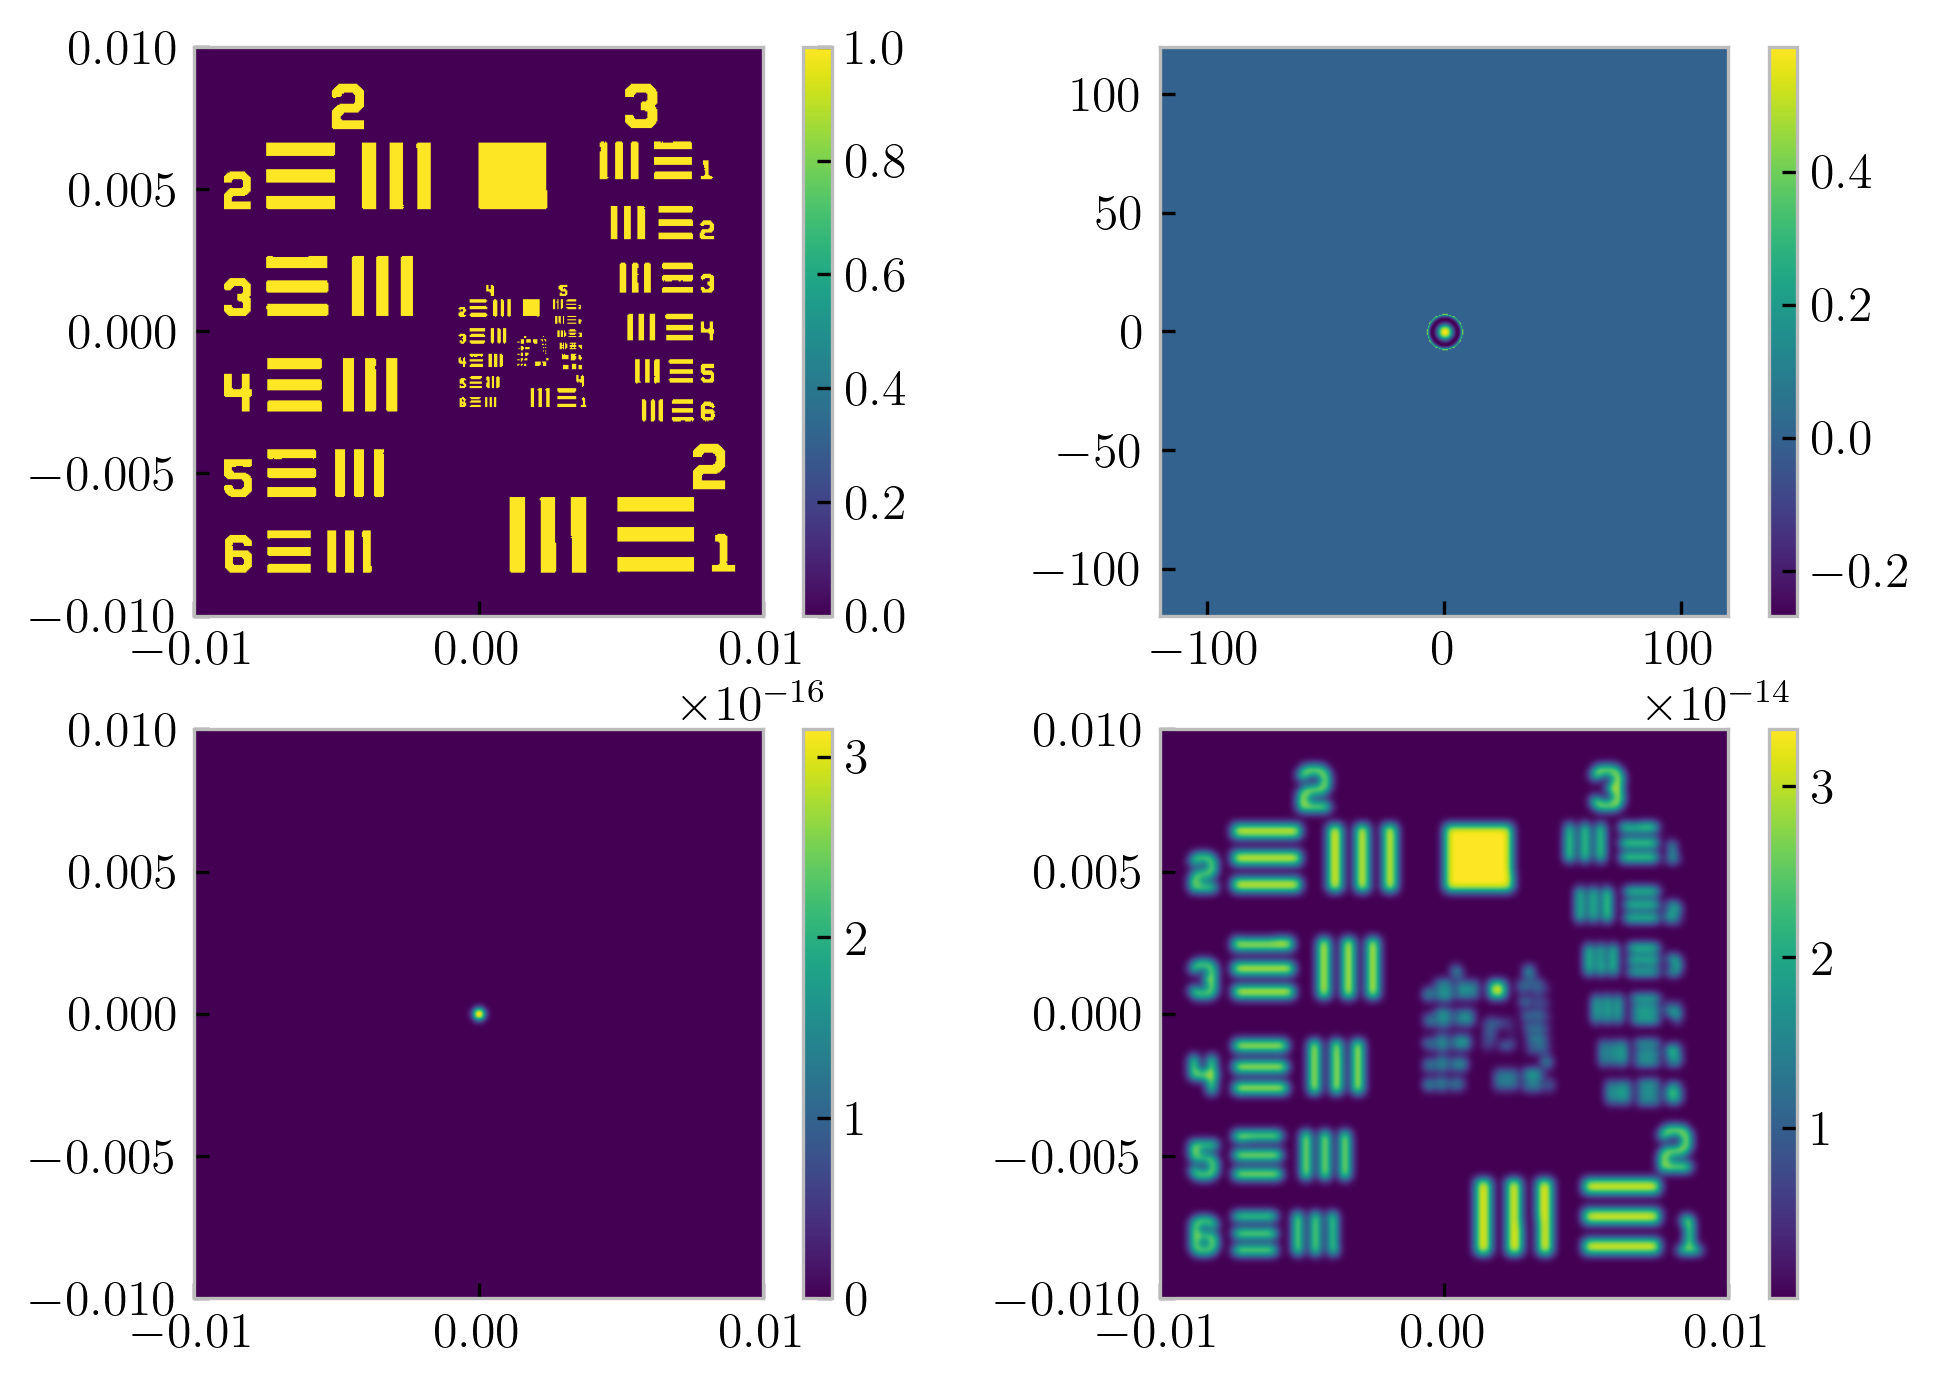

In [24]:
rng = np.random.default_rng(15)
mean = 0
std_dev = .5e-17

H = forward_H(microscope, true_aberration)
PSF = forward_PSF(microscope, true_aberration)
#plot_intensity(x, y, PSF, normalize = False)
d = forward_image(microscope, f, true_aberration)
#d = add_gaussian_noise(d, mean, std_dev, rng)
#plot_intensity(x, y, d, normalize = False)

fig, axs = plt.subplots(2, 2)
axs = axs.flatten()

im0 = axs[0].imshow(f,
                    extent=[x[0], x[-1], y[0], y[-1]],)

im1 = axs[1].imshow(np.imag(H),
                    extent=[x_bfp[0], x_bfp[-1], y_bfp[0], y_bfp[-1]],)

im2 = axs[2].imshow(PSF,
                    extent=[x[0], x[-1], y[0], y[-1]],)

im3= axs[3].imshow(d,
                   extent=[x[0], x[-1], y[0], y[-1]],)

for ax in axs:
    ax.grid(False)
    #ax.set_xticks([])
    #ax.set_yticks([])



fig.colorbar(im0, ax = axs[0])
fig.colorbar(im1, ax = axs[1])
fig.colorbar(im2, ax = axs[2])
fig.colorbar(im3, ax = axs[3])

In [25]:
bias_modes = [[0,4], [-2,2]]
bias_strength = 0.5
a_stack = [EmptyAberration()] + [Aberration([m], [bias_strength]) for m in bias_modes]
d_stack = np.array([get_diversity_image(microscope, f, true_aberration, a) for a in a_stack])
#d_stack = [add_gaussian_noise(d, mean, std_dev, rng) for d in d_stack]

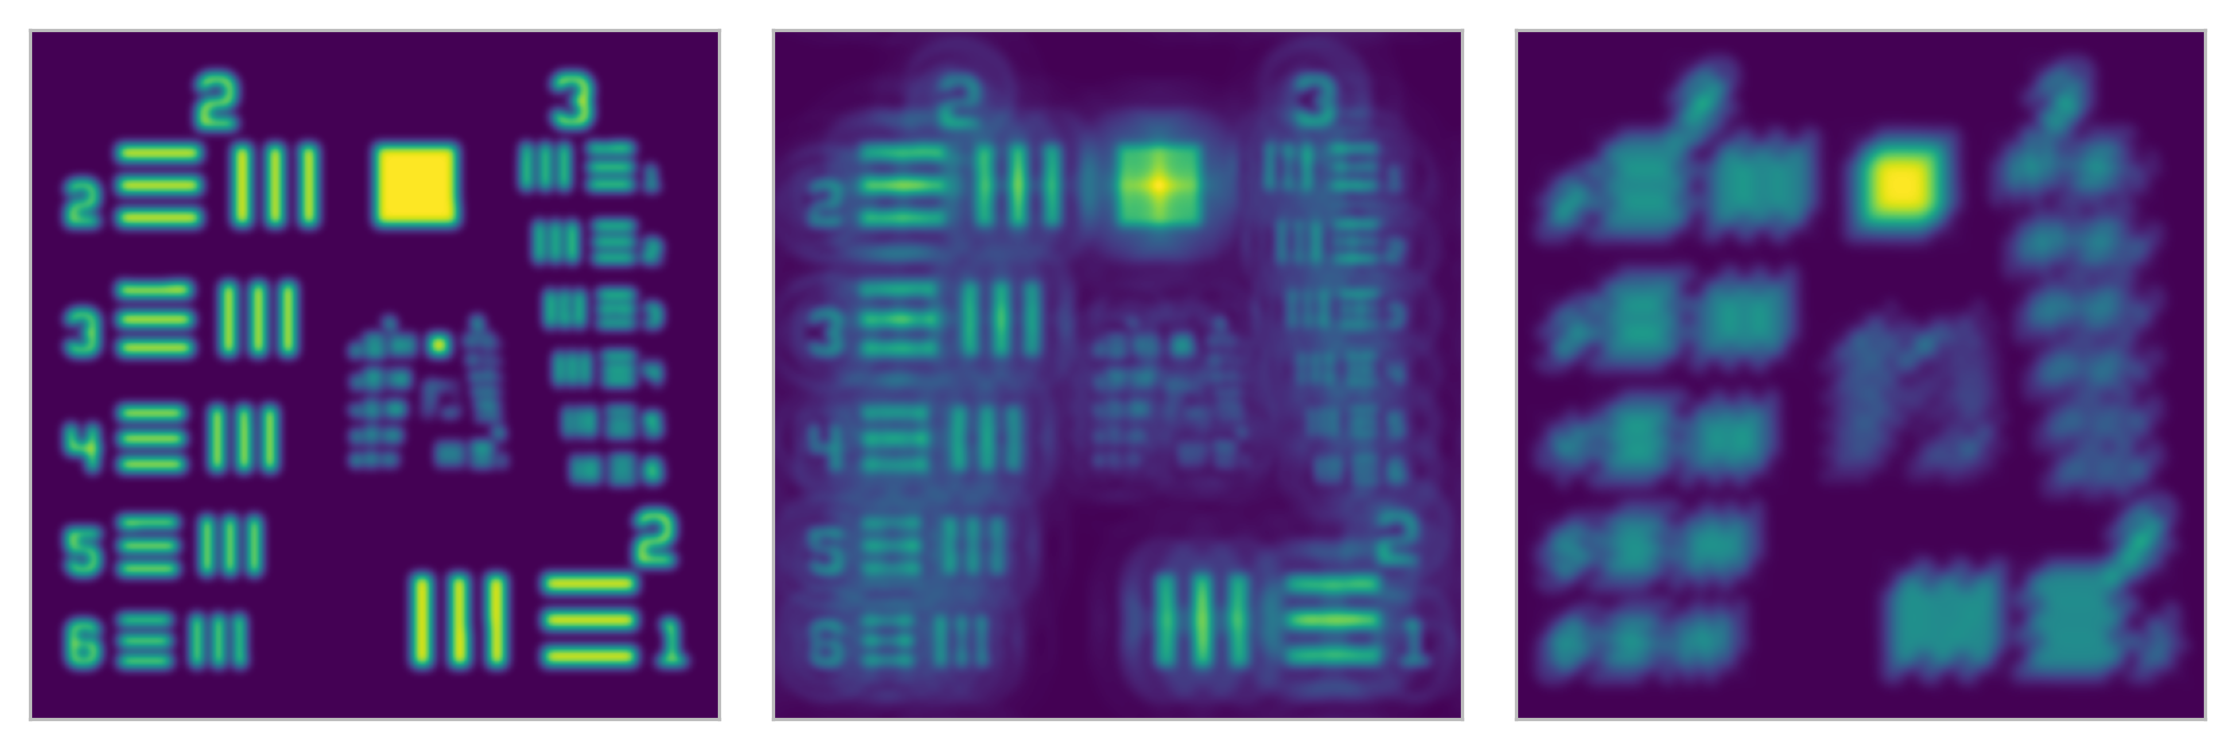

In [26]:
a = 1
b = 3
fig, axs = plt.subplots(a, b, layout = "tight")
axs = axs.flatten()
for i in range(a*b):
    axs[i].imshow(d_stack[i])
    axs[i].grid(False)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

In [28]:
gamma_vals = np.flip([1 * 10**(-2*x) for x in range(10)])
gamma_vals


N_orders = np.array([1,2,3])
c_converged = np.zeros(len(gamma_vals) * len(N_orders))

for j, N_order in enumerate(N_orders):
    for i, gamma in tqdm(enumerate(gamma_vals)):

        microscope = Microscope(N_order, lambd, n, num_apt, f, mag, w_0, L_bfp, grid_bfp)
        params = {
            "gamma": gamma,
            "rate": 1,
            "threshold" : 0.2,
            "threshold_damper": 0.99
        }

        bias_modes = [
        [-2, 2], [0, 2], [2, 2],
        [-3, 3], [-1, 3], [1, 3], [3, 3],
        [-4, 4], [-2, 4], [0, 4], [2, 4], [4, 4]]
        bias_strength = 0.5
        a_stack = [EmptyAberration()] + [Aberration([m], [bias_strength]) for m in bias_modes]

        true_aberration = Aberration([[0,4]], [0.2])

        d_stack = np.array([get_diversity_image(microscope, f, true_aberration, a) for a in a_stack])
        
        modes_corrected = [[0, 4]]

        c_guess, F_guess, c_guess_log, F_guess_log, J_log  = loop_optimize(n_loops = 5,
                                        microscope = microscope,
                                        d_stack = d_stack,
                                        a_stack = a_stack,
                                        modes_corrected = modes_corrected,
                                        params = params,
                                        debug = False,
                                        log = True)
        
        c_converged[j*len(gamma_vals) + i] = c_guess[0]

  0%|          | 0/5 [00:02<?, ?it/s]
2it [00:33, 16.58s/it]


KeyboardInterrupt: 

In [47]:
gamma_vals

array([1.e-27, 1.e-24, 1.e-21, 1.e-18, 1.e-15, 1.e-12, 1.e-09, 1.e-06,
       1.e-03, 1.e+00])

In [48]:
c_converged

array([0.08134773, 0.08134773, 0.08134773, 0.08134773, 0.08134773,
       0.08134773, 0.08134773, 0.08134773, 0.08134773, 0.08134773])

In [49]:
aberrations_determined = [Aberration(true_modes, [c]) for c in c_converged]
rms = [zernike_RMS(a_determined, true_aberration, alpha) for a_determined in aberrations_determined]

ValueError: x and y must have same first dimension, but have shapes (10,) and (0,)

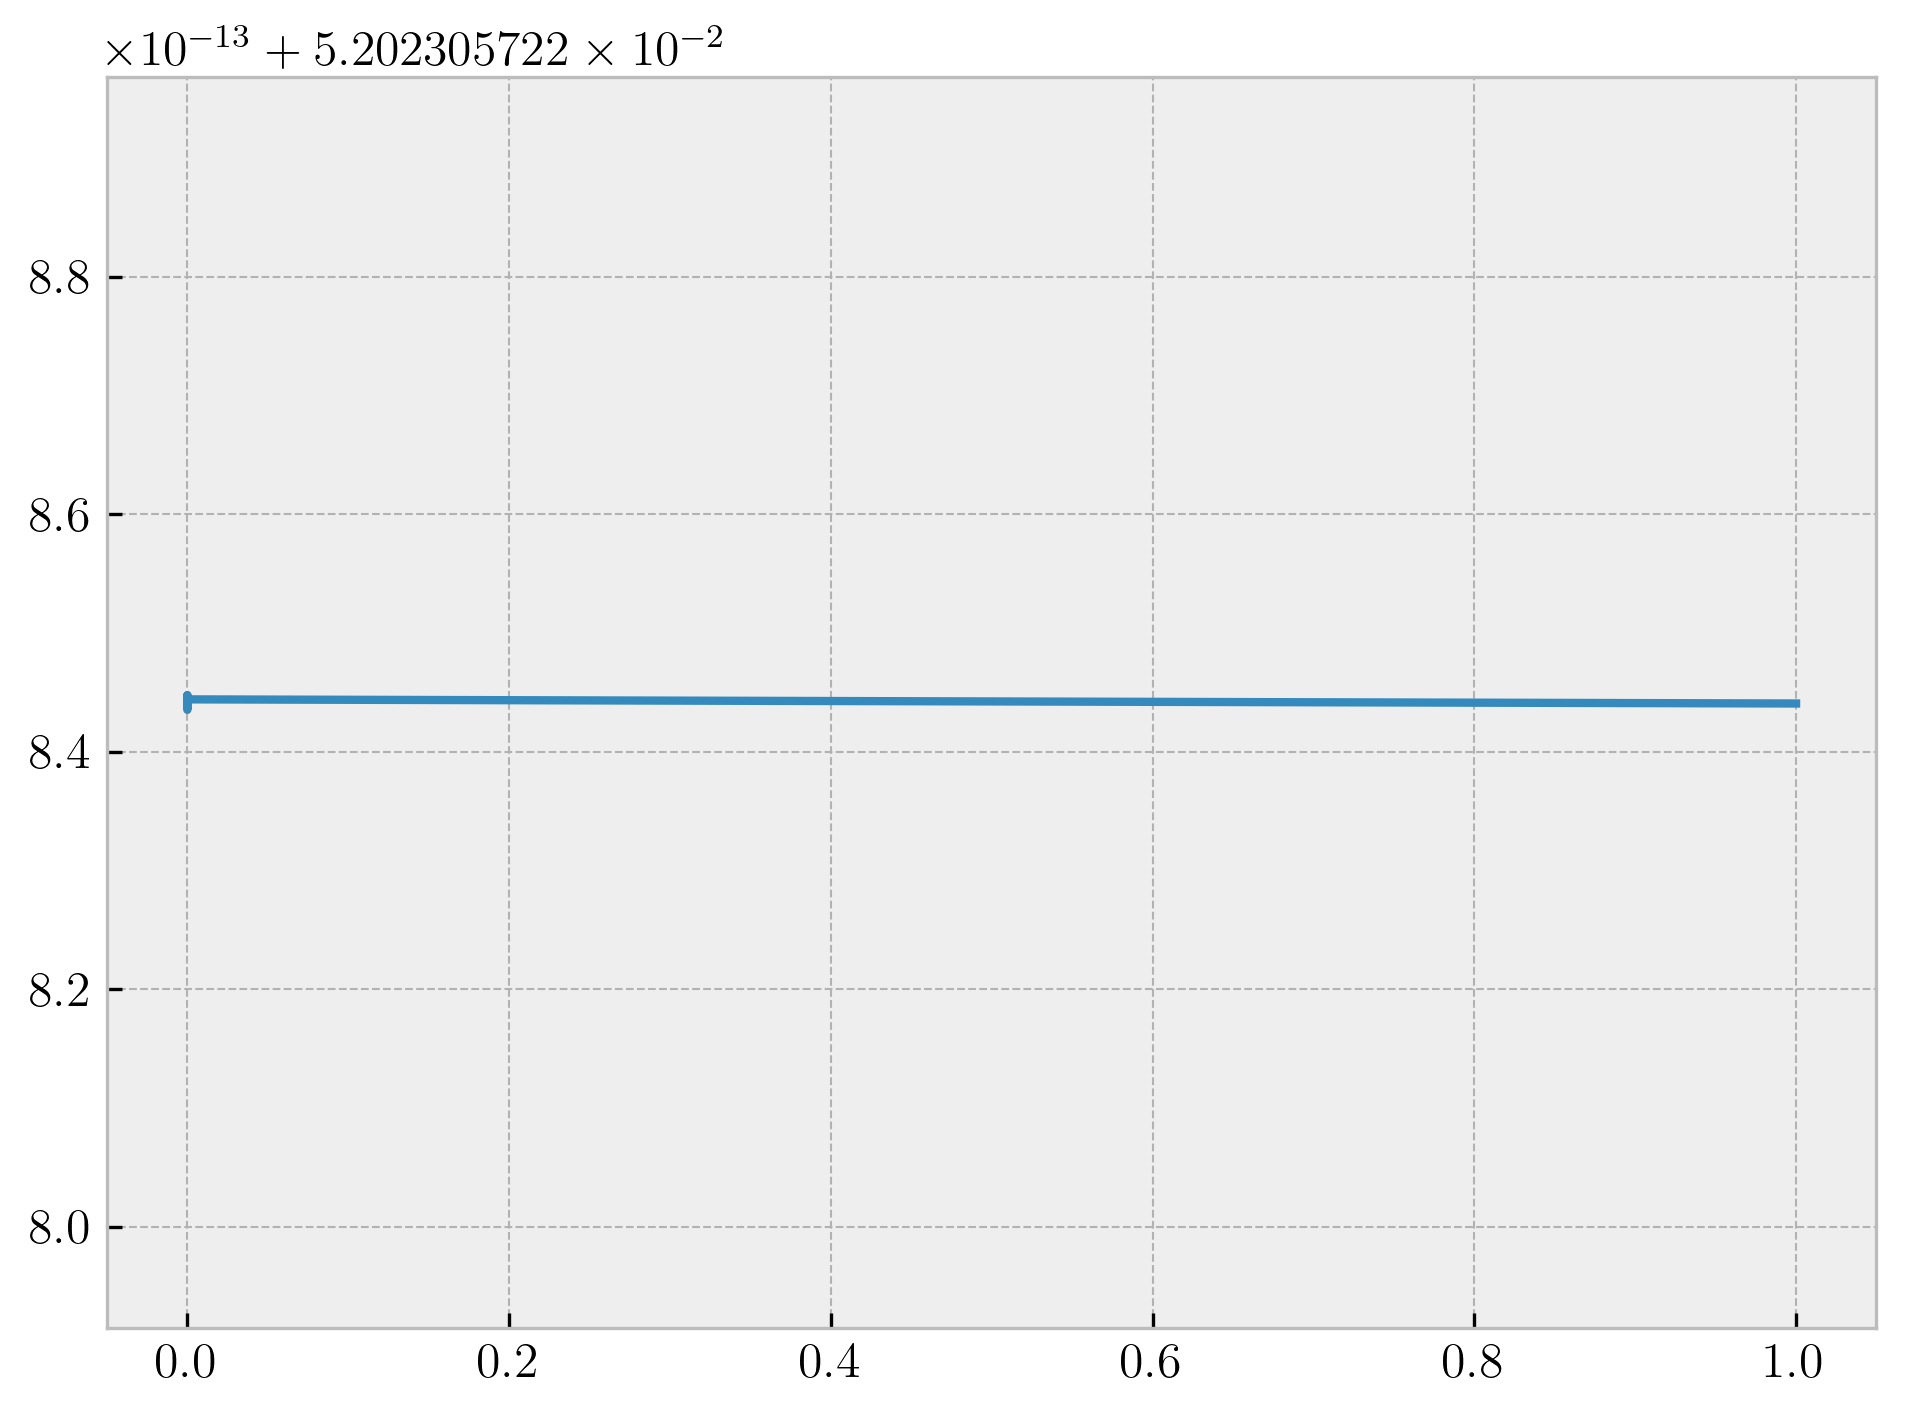

In [50]:
fig, ax = plt.subplots(dpi = 300)
for i in range(3):
    ax.plot(gamma_vals, rms[i*len(gamma_vals):(i+1)*len(gamma_vals)], label = f"{i+1}P")
ax.legend()
ax.set_xscale("log")